#MÔ HÌNH YOLOV1 GIÚP DỰ ĐOÁN ĐÈN ĐỎ VỚI DỮ LIỆU LẤY TỪ public.roboflow.

## Tải thư viện cần thiết

In [ ]:
import torch.nn as nn
import torch
import torchvision
import numpy as np
from torch.utils.data import Dataset
import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

## Dựng mô hình theo cấu trúc bài báo, tuy nhiên có cập nhật thêm batch normalization

In [2]:
architecture_config = [
    # Tuple: (kernel_size, out_channels, strides, paddings)
    (7,74,2,3),
    "M",
    (1, 192, 1, 1),
    "M",
    (1, 128, 1, 0),
    (3, 256, 1, 1),
    (1, 256, 1, 0),
    (3, 512, 1, 1),
    "M",
    # List: tuples and then last integer represents number of repeats
    [(1, 256, 1, 0), (3, 512, 1, 1), 4],
    (1, 512, 1, 0),
    (3, 1024, 1, 1),
    "M",
    [(1, 512, 1, 0), (3, 1024, 1, 1), 2],
    (3, 1024, 1, 1),
    (3, 1024, 2, 1),
    (3, 1024, 1, 1),
    (3, 1024, 1, 1)
]


class CNNBlock(nn.Module):
  def __init__(self, in_channels, out_channels, **kwargs):
    super().__init__()
    self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
    self.batchnorm = nn.BatchNorm2d(out_channels)
    self.leakyrelu = nn.LeakyReLU(0.1)

  def forward(self, x):
    return self.leakyrelu(self.batchnorm(self.conv(x)))

class Yolov1(nn.Module):
    def __init__(self, in_channels=3, **kwargs):
      super().__init__()
      self.architecture = architecture_config
      self.in_channels = in_channels
      self.darknet = self._create_conv_layers(self.architecture)
      self.fcs = self._create_fcs(**kwargs)

    def forward(self, x):
      x = self.darknet(x)
      return self.fcs(torch.flatten(x, start_dim=1))
    def _create_conv_layers(self, architecture):
      layers=[]
      in_channels = self.in_channels

      for x in architecture:
        if type(x) == tuple:
          layers += [CNNBlock(in_channels,out_channels=x[1], kernel_size=x[0], stride=x[2], padding=x[3])]
          in_channels = x[1]
        elif type(x) == str:
          layers += [nn.MaxPool2d(kernel_size=(2,2), stride=2)]
        elif type(x) == list:
          conv1 = x[0] #Tuple
          conv2 = x[1] #Tuple
          num_repeats = x[2] #Interger
          for _ in range(num_repeats):
            layers += [
                CNNBlock(
                    in_channels,
                    conv1[1],
                    kernel_size=conv1[0],
                    stride=conv1[2],
                    padding=conv1[3]
                )
            ]
            in_channels = conv1[1]
            layers += [
                CNNBlock(
                    conv1[1],
                    conv2[1],
                    kernel_size=conv2[0],
                    stride=conv2[2],
                    padding=conv2[3]
                )
            ]
            in_channels=conv2[1]
      return nn.Sequential(*layers)

    def _create_fcs(self, split_size, num_boxes, num_classes):
      S, B, C = split_size, num_boxes, num_classes
      return nn.Sequential(
          nn.Flatten(),
          nn.Linear(1024*S*S, 496),
          nn.Dropout(0.5),
          nn.LeakyReLU(0.1),
          nn.Linear(496, S*S*(C+B*5))
      )



# The test
def test(split_size=7, num_boxes=2, num_classes=1):
  #model = Yolov1(split_size, num_boxes, num_classes)
  model = Yolov1(split_size=split_size, num_boxes=num_boxes, num_classes=num_classes)
  x = torch.randn((2,3,448,448))
  #print(model(x).shape)
  return model(x)

xx = test()

print(xx.view(-1, 7, 7, 5*2 + 1).shape)
# Cách dựng mô hình này hay, idea từ Mr. Aladdin

torch.Size([2, 7, 7, 11])


## Hàm vẽ Bounding Boxes

In [4]:
# Lấy một hình bất kỳ
img_path = '/content/drive/MyDrive/2025/Dataset/Helmet/Train/1000_Image/000028_jpg.rf.ecbc2b8b93727ac8114ce442f27d6ee4.jpg'
ann_path = '/content/drive/MyDrive/2025/Dataset/Helmet/Train/1000_Annotation/000028_jpg.rf.ecbc2b8b93727ac8114ce442f27d6ee4.txt'

In [5]:
# Thư mục chứa dữ liệu traffic light (đỏ) lấy từ Roboflow
image_path = "/content/drive/MyDrive/2025/Dataset/Traffic_light/image"

annotation_path = "/content/drive/MyDrive/2025/Dataset/Traffic_light/annotation"

# File paths cho hình ảnh
image_path_all = [os.path.join(image_path, fname) for fname in os.listdir(image_path)]
# File paths cho annotations
annotation_path_all = [os.path.join(annotation_path, fname) for fname in os.listdir(annotation_path)]

# Sắp xếp theo thứ tự tăng dần az19
img_dir = sorted(image_path_all)
anno_dir = sorted(annotation_path_all)

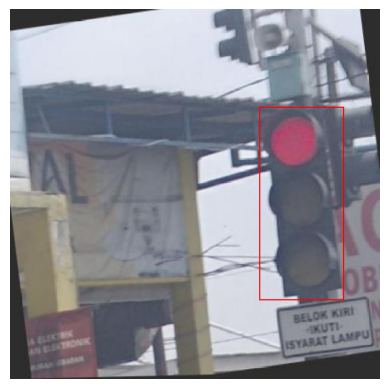

In [6]:
def DrawBoundingBox(annotation_path, image_path):
    """Input:
    annotation: the .txt file
    image: the .jpg file
    Output: none, chỉ vẽ bounding box khi gọi
    """
    bbox = []
    with open(annotation_path, 'r') as f:
        for line in f:
          bbox.append([float(x) if '.' in x  else int(x) for x in line.strip().split(" ")])

    #print(type(lines[0]))
    image = Image.open(image_path)
    image_np = np.array(image)


    image_height,image_width, _ = image_np.shape
    #class_name, x_center, y_center, width, height = bbox[1]
    for box in bbox:
      class_name, x_center, y_center, width, height = box
      # Chuyển đổi tọa độ đã chuẩn hóa thành giá trị pixel.
      x_center_pixel = int(x_center * image_width)
      y_center_pixel = int(y_center * image_height)
      width_pixel = int(width * image_width)
      height_pixel = int(height * image_height)

      # Tính toán tọa độ góc trên bên trái và góc dưới bên phải của bounding box
      x_min = int(x_center_pixel - width_pixel / 2)
      y_min = int(y_center_pixel - height_pixel / 2)
      x_max = x_min + width_pixel
      y_max = y_min + height_pixel

      if class_name <= 1:
        draw = ImageDraw.Draw(image)

        # Vẽ bounding box (dùng màu đỏ)
        draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)


    # Hiển thị hình ảnh cùng bounding box
    plt.imshow(image)
    plt.axis('off')
    plt.show()


img = img_dir[1000]
ann = anno_dir[1000]
# img = "/content/22.jpg"
# ann = "/content/22.txt"


DrawBoundingBox(ann, img)

## Tạo custom dataset

In [8]:
class TrafficLightDataset(Dataset):
    def __init__(self, anno_paths, image_paths, S=7, B=2, C=2, transform=None, return_eval=False):
        self.anno_paths = anno_paths
        self.image_paths = image_paths
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C
        self.return_eval = return_eval  # Trả về cấu trúc YOLODarknet ban đầu

    def __len__(self):
        return len(self.anno_paths)

    def __getitem__(self, index):
        boxes = []
        labels = []
        annotation = self.anno_paths[index]
        image_path = self.image_paths[index]

        image = Image.open(image_path)
        image_np = np.array(image)
        image_height, image_width, _ = image_np.shape

        # Label grid (for training)
        label_grid = np.zeros((self.S, self.S, self.C + 5 + 4))

        with open(annotation, 'r') as f:
            for line in f:
                box = [float(x) if '.' in x else int(x) for x in line.strip().split(" ")]
                class_name, x_center, y_center, width, height = box

                # Convert normalized coordinates to pixel values
                x_center_pixel = int(x_center * image_width)
                y_center_pixel = int(y_center * image_height)
                width_pixel = int(width * image_width)
                height_pixel = int(height * image_height)

                # Convert to (x_min, y_min, x_max, y_max)
                x_min = int(x_center_pixel - width_pixel / 2)
                y_min = int(y_center_pixel - height_pixel / 2)
                x_max = x_min + width_pixel
                y_max = y_min + height_pixel

                if not self.return_eval:
                    # TRAINING MODE: Store in label grid
                    x_cell = x_center * self.S - int(x_center * self.S)
                    y_cell = y_center * self.S - int(y_center * self.S)
                    width_cell = width * self.S
                    height_cell = height * self.S

                    col = int(x_center * self.S)
                    row = int(y_center * self.S)

                    if class_name <= 1:  # Only hat and head
                        label_grid[row, col, 0] = 1  # Object present
                        label_grid[row, col, 1:5] = x_cell, y_cell, height_cell, width_cell
                        label_grid[row, col, 5] = class_name
                        label_grid[row, col, -4:] = (x_min, y_min, x_max, y_max)
                else:
                    # EVALUATION MODE: Store in mAP format
                    boxes.append([x_min, y_min, x_max, y_max])
                    labels.append(class_name)

        # Convert to PyTorch tensors
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.tensor(image_np, dtype=torch.float32).permute(2, 0, 1)  # Convert to (C, H, W)

        if self.return_eval:
            # Return evaluation format
            target = {
                "boxes": torch.tensor(boxes, dtype=torch.float32),
                "labels": torch.tensor(labels, dtype=torch.int64),
            }
            return image, target
        else:
            # Return training format
            return image, torch.tensor(label_grid, dtype=torch.float32)

d1 = TrafficLightDataset(anno_dir,img_dir,return_eval=False)
ann_path, img_path = d1[100]
#DrawBoundingBox(ann_path, img_path)
# #bx, anno, img, _  = d1[1]
# result = d1[100]
# print(result)#[1][1,1,:])

In [10]:
def intersection_over_union(boxes_preds, boxes_labels):


    # Chuyển bounding box từ dạng YOLO sang x_min, y_min, x_max, y_max
    box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
    box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
    box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
    box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2

    box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
    box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
    box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
    box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    # Tìm tọa độ của intersection
    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    # Tính intersection area
    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    # Tính diện tích của 2 bounding boxes
    box1_area = (box1_x2 - box1_x1) * (box1_y2 - box1_y1)
    box2_area = (box2_x2 - box2_x1) * (box2_y2 - box2_y1)

    # Tính diện tích union
    union = box1_area + box2_area - intersection

    # Tính iou
    iou = intersection / union.clamp(min=1e-6)  # Avoid division by zero
    return iou

# Tiến hành kiểm tra hàm intersection_over_union
# Prediction
target = torch.zeros((1,7,7,6))
target[0][1,2,0] = 1
target[0][1,2,1:5] = torch.tensor([0.2, 0.5, 1.5, 2.3])
target[0][1,2,5] = 1

pred = torch.zeros((1,7,7,11))
pred[...,1,2,0] = 1
pred[...,1,2,1:5] = torch.tensor([0.3, 0.4, 1.4, 2.1])
pred[...,1,2,5] = 1
pred[...,1,2,6:10] = torch.tensor([0.1, 0.4, 1.5, 2.5])
pred[...,1,2,10] = 1
intersection_over_union(pred, target)

tensor([[[[0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000]],

         [[0.0000],
          [0.0000],
          [0.7013],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000]],

         [[0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000]],

         [[0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000]],

         [[0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000]],

         [[0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000]],

         [[0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000],
          [0.0000]]]])

## Hàm lỗi YoloLoss

In [12]:
class YoloLoss(nn.Module):

  def __init__(self, S=7, B=2, C=1):
    super().__init__()
    self.mse = nn.MSELoss(reduction='sum')
    self.S = S
    self.B = B
    self.C = C
    self.lambda_noobj = 0.5
    self.lambda_coord = 5

  def forward(self, predictions, target):

    # Output của mỗi grid cell
    # [object?, x1, y1, width1, height1, class1, x2, y2, width2, height2, class2]

    predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B*5)
    iou_b1 = intersection_over_union(predictions[...,1:5], target[...,1:5])
    iou_b2 = intersection_over_union(predictions[...,6:10], target[...,1:5])
    # print(target[...,1:5].shape)
    # print(predictions[...,6:10].shape)
    # print(iou_b1)


    ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)
    max_iou, best_box_idx = torch.max(ious, dim=0)

    is_box = target[...,0].unsqueeze(3)

    ## Box coordinates

    box_predictions = is_box * (
        (
            best_box_idx  * predictions[..., 6:10] +
            (1 - best_box_idx) * predictions[...,1:5]
        )
    ) # => Lựa bounding box có iou cao nhất

    box_targets = is_box * target[...,1:5]


    transformed_box_predictions = torch.sign(box_predictions[..., 3:5]) * \
    torch.sqrt(torch.abs(box_predictions[..., 3:5]) + 1e-6)

    box_predictions = box_predictions.clone()
    box_predictions[..., 3:5] = transformed_box_predictions


    box_loss = self.mse(
        torch.flatten(box_predictions, end_dim=-2),
        torch.flatten(box_targets,end_dim=-2)
    )

    # Object loss (C): có hay không có bất kỳ đối tượng nào trong grid cell


    object_loss = self.mse(
        torch.flatten(is_box * predictions[..., 0:1]),
        torch.flatten(is_box * target[...,0:1])
    )

    # No object loss
    no_object_loss = self.mse(
        torch.flatten((1-is_box) * predictions[..., 0:1]),
        torch.flatten((1-is_box) * target[...,0:1])
    )

    # Class loss: Xác suất lớp cho bounding box có giá trị iou cao nhất



    best_box_for_class = is_box * (
        (
            best_box_idx  * predictions[..., 5:6] +
            (1 - best_box_idx) * predictions[...,10:11]
        )
    ) # => Chọn một bounding box tốt nhất để tính toán xác suất lớp so với ground truth.
    class_loss = self.mse(
        torch.flatten(best_box_for_class, end_dim=-2),
        torch.flatten(is_box * target[..., 5:6], end_dim=-2)
    )

    loss = (
        self.lambda_coord * box_loss + \
        object_loss + self.lambda_noobj * no_object_loss +\
        class_loss
    )
    return loss

# Định nghĩa các tham số

S = 7  # Grid size
B = 2  # Số lượng bounding box
C = 1  # Số lớp: vì chỉ để nhận biết một lớp là traffic red light
input_dim = C + B * 5  # Tổng số giá trị trên mỗi grid cell

# Prediction
target = torch.zeros((1,7,7,6))
target[0][1,2,0] = 1
target[0][1,2,1:5] = torch.tensor([0.2, 0.5, 1.5, 2.3])
target[0][1,2,5] = 1

pred = torch.zeros((1,7,7,11))
pred[...,1,2,0] = 1
pred[...,1,2,1:5] = torch.tensor([0.3, 0.4, 1.4, 2.1])
pred[...,1,2,5] = 1
pred[...,1,2,6:10] = torch.tensor([0.1, 0.4, 1.5, 2.5])
pred[...,1,2,10] = 1
pred.shape
#print(target.shape)

yolo_loss = YoloLoss(S=S, B=B, C=C)



#print(pred[1,2,1:5].shape)
# # Compute loss
loss = yolo_loss(pred, target)
print(loss)

tensor(2.6838)


In [14]:
model = Yolov1(split_size=7, num_boxes=2, num_classes=1)
#print(model)


In [15]:
# Định nghĩa một số tham số
batch_size = 8
num_workers = 2
# Một số transform trên dữ liệu
resize_transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor()
])
# Tạo dataset
dataset = TrafficLightDataset(anno_paths=anno_dir, image_paths=img_dir, return_eval=False, transform=resize_transform)

# Tạo DataLoader
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

In [16]:
# Kiểm tra thử 1 batch
data_iter = iter(dataloader)  # Tạo iterator
images, labels = next(data_iter)  # Lấy batch đầu tiên
print(images.shape)

torch.Size([8, 3, 448, 448])


In [24]:
# Định nghĩa hàm train cho mỗi bước
losses = []
def train_one_step(model, data_loader, optimizer, loss_fn, device="cuda", learning_rate=1e-5, S=7, B=2, C=1):
    model.train()  # Đặt mô hình vào chế độ train
    total_loss = 0

    for batch_idx, (images, targets) in enumerate(data_loader):
        batch_idx += 1
        images, targets = images.to(device), targets.to(device)  # Move data to the specified device


        optimizer.zero_grad()  # Cho gradients = 0
        predictions = model(images)  # Forward pass

        predictions = predictions.view(-1, S, S, C + B*5)
        #print(predictions.shape)
        #print(predictions.shape)
        #print(targets.shape)

        loss = loss_fn(predictions, targets)  # Tính loss
        losses.append(loss.item())


        loss.backward()  # Backpropagation
        optimizer.step()  # Cập nhật tham số của mô hình

        total_loss += loss.item()

        print(f'loss = {loss}') # In kết quả loss của mỗi batch
    avg_loss = total_loss / len(data_loader)  # Tính kết quả loss của tất cả các batch trung bình lại
    return avg_loss




# Hyperparameters cho training
NUM_EPOCHS = 2
LEARNING_RATE = 1e-5
BATCH_SIZE = 8
DEVICE = "cuda" if torch.cuda.is_available() else "cpu" # Bài này dùng CPU, không có cuda (nhưng convention thường làm vậy)

model = model.to(DEVICE)  # Nếu có cuda
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = YoloLoss(S=7, B=2, C=1)


torch.autograd.set_detect_anomaly(True) # Vì nhiều bugs, nên đặt method này để kiểm tra lỗi từ đâu.
# Training Loop
for epoch in range(NUM_EPOCHS):
    avg_loss = train_one_step(model, dataloader, optimizer, loss_fn, DEVICE, LEARNING_RATE)


    #print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_loss:.4f}")

print("Training Complete!")
# Do batch nhỏ (8 hình), nên sẽ có sự dao động lớn về lỗi

loss = 266.15692138671875
loss = 374.32257080078125
loss = 407.1094055175781
loss = 326.1756896972656
loss = 397.2918395996094
loss = 447.03839111328125
loss = 453.2165832519531
loss = 249.03131103515625
loss = 342.7320556640625
loss = 207.6543426513672
loss = 569.2374267578125
loss = 243.36666870117188
loss = 282.8173828125
loss = 233.37615966796875
loss = 238.39212036132812
loss = 306.2843017578125
loss = 255.58738708496094
loss = 562.587158203125
loss = 293.2273254394531
loss = 338.1376037597656
loss = 293.67120361328125
loss = 344.1272277832031
loss = 293.0640869140625
loss = 366.4659423828125
loss = 187.93057250976562
loss = 146.62338256835938
loss = 244.77462768554688
loss = 385.6048583984375
loss = 218.79348754882812
loss = 338.9344482421875
loss = 175.0409393310547
loss = 250.89236450195312
loss = 403.22528076171875
loss = 274.9357604980469
loss = 251.81259155273438
loss = 277.0867919921875
loss = 261.40484619140625
loss = 209.57656860351562
loss = 554.8850708007812
loss = 264.